In [97]:
import scanpy as sc
import squidpy as sq
from squidpy.im import ImageContainer
import numpy as np
import pandas as pd
from anndata import AnnData
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import skimage
import seaborn as sns
import tangram as tg
import torch

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

%load_ext autoreload
%autoreload 2
%matplotlib inline

scanpy==1.10.3 anndata==0.10.9 umap==0.5.9.post2 numpy==1.26.4 scipy==1.13.1 pandas==2.3.1 scikit-learn==1.6.1 statsmodels==0.14.5 igraph==0.11.9 pynndescent==0.5.13
squidpy==1.6.1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
adata_sc = sc.read_h5ad('/Users/rikac/Documents/mansfield_lab/summer_25/bc3306_final_adata.h5ad')
adata_st = sc.read_h5ad('/Users/rikac/Documents/mansfield_lab/summer_25/visium_sample_dataset.h5ad')

In [3]:
adata_sc

AnnData object with n_obs × n_vars = 23299 × 18973
    obs: 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'doublet_scores', 'predicted_doublets', 'batch', 'leiden_0.01', 'leiden_0.025', 'leiden_0.05', 'leiden_0.1', 'leiden_0.15', 'leiden_0.2', 'leiden_0.4', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DGEleiden0.01', 'DGEleiden0.025', 'DGEleiden0.05', 'DGEleiden0.1', 'DGEleiden0.15', 'DGEleiden0.2', 'DGEleiden0.4', 'ebf2+_sox9+_col2a1+_colors', 'ebf2+_sox9+_col2a1-_colors', 'hvg', 'leiden_0.01', 'leiden_0.01_colors', 'leiden_0.025', 'leiden_0.025_colors', 'leiden_0.05', 'leiden_0.05_

In [4]:
adata_st

AnnData object with n_obs × n_vars = 6442 × 19465
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'summary_ch-0_mean', 'image_features_clusters', 'leiden_expr_spatial', 'leiden_expr_spatial_scaled'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'image_features_clusters', 'image_features_clusters_colors', 'leiden', 'leiden_colors', 'leiden_expr_spatial', 'leiden_expr_spatial_colors', 'leiden_expr_spatial_scaled', 'leiden_expr_spatial_scaled_colors', 'log1p', 'moranI', 'neighbors', 'pca', 'rank_genes_

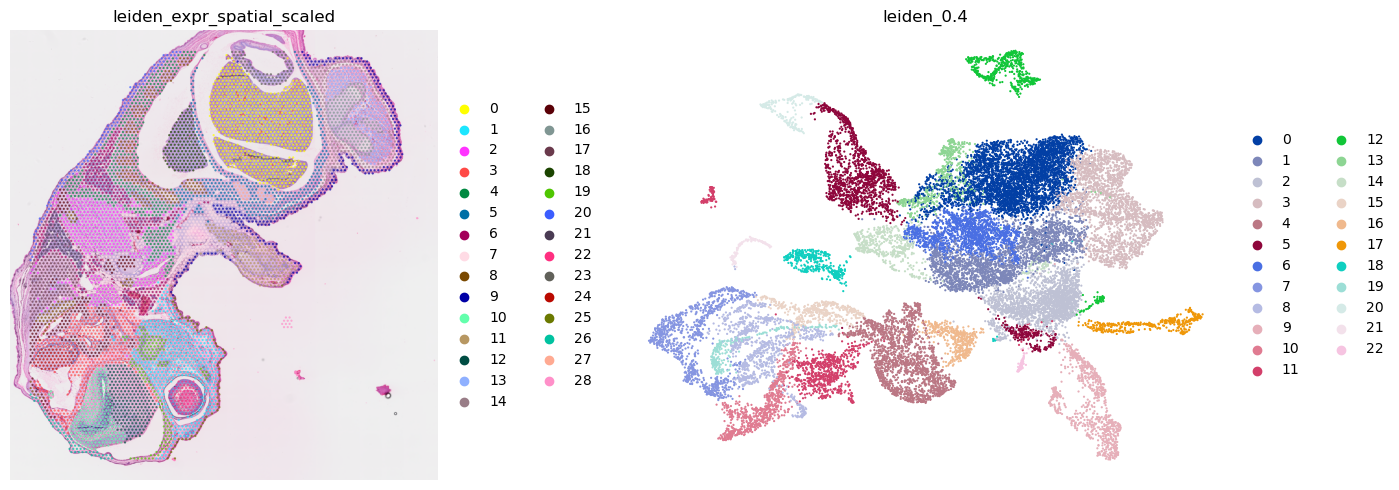

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sc.pl.spatial(adata_st, color="leiden_expr_spatial_scaled", alpha=0.7, frameon=False, show=False, ax=axs[0])
sc.pl.umap(adata_sc, color="leiden_0.4", size=10, frameon=False, show=False, ax=axs[1])
plt.tight_layout()

In [6]:
# get training markers
sc.tl.rank_genes_groups(adata_sc, groupby="leiden_0.4", use_raw=False)
markers_df = pd.DataFrame(adata_sc.uns["rank_genes_groups"]["names"]).iloc[0:100, :]
markers = list(np.unique(markers_df.melt().value.values))
len(markers)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


1650

In [7]:
tg.pp_adatas(adata_sc, adata_st, genes=markers)

INFO:root:1351 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:14538 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [8]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

ad_map = tg.map_cells_to_space(adata_sc, adata_st,
    mode="cells",
    # mode="clusters",
    # cluster_label='cell_subclass',  # .obs field w cell types
    density_prior='rna_count_based',
    num_epochs=500,
    device=device
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 1351 genes and rna_count_based density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.642, KL reg: 0.011
Score: 0.841, KL reg: 0.000
Score: 0.855, KL reg: 0.000
Score: 0.859, KL reg: 0.000
Score: 0.860, KL reg: 0.000


INFO:root:Saving results..


In [9]:
ad_map.write_h5ad('/Users/rikac/Documents/mansfield_lab/summer_25/ad_map.h5ad')

In [10]:
ad_map

AnnData object with n_obs × n_vars = 23299 × 6442
    obs: 'sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'doublet_scores', 'predicted_doublets', 'batch', 'leiden_0.01', 'leiden_0.025', 'leiden_0.05', 'leiden_0.1', 'leiden_0.15', 'leiden_0.2', 'leiden_0.4', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-'
    var: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'summary_ch-0_mean', 'image_features_clusters', 'leiden_expr_spatial', 'leiden_expr_spatial_scaled', 'uniform_density', 'rna_count_based_density'
    uns: 'train_genes_df', 'training

The mapping results are stored in the returned AnnData structure, saved as `ad_map`, structured as following:

* The cell-by-spot matrix X contains the probability of cell `i` to be in spot `j`.
* The `obs` dataframe contains the metadata of the single cells.
* The `var` dataframe contains the metadata of the spatial data.
* The `uns` dictionary contains a dataframe with various information about the training genes (saved as `train_genes_df`).

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


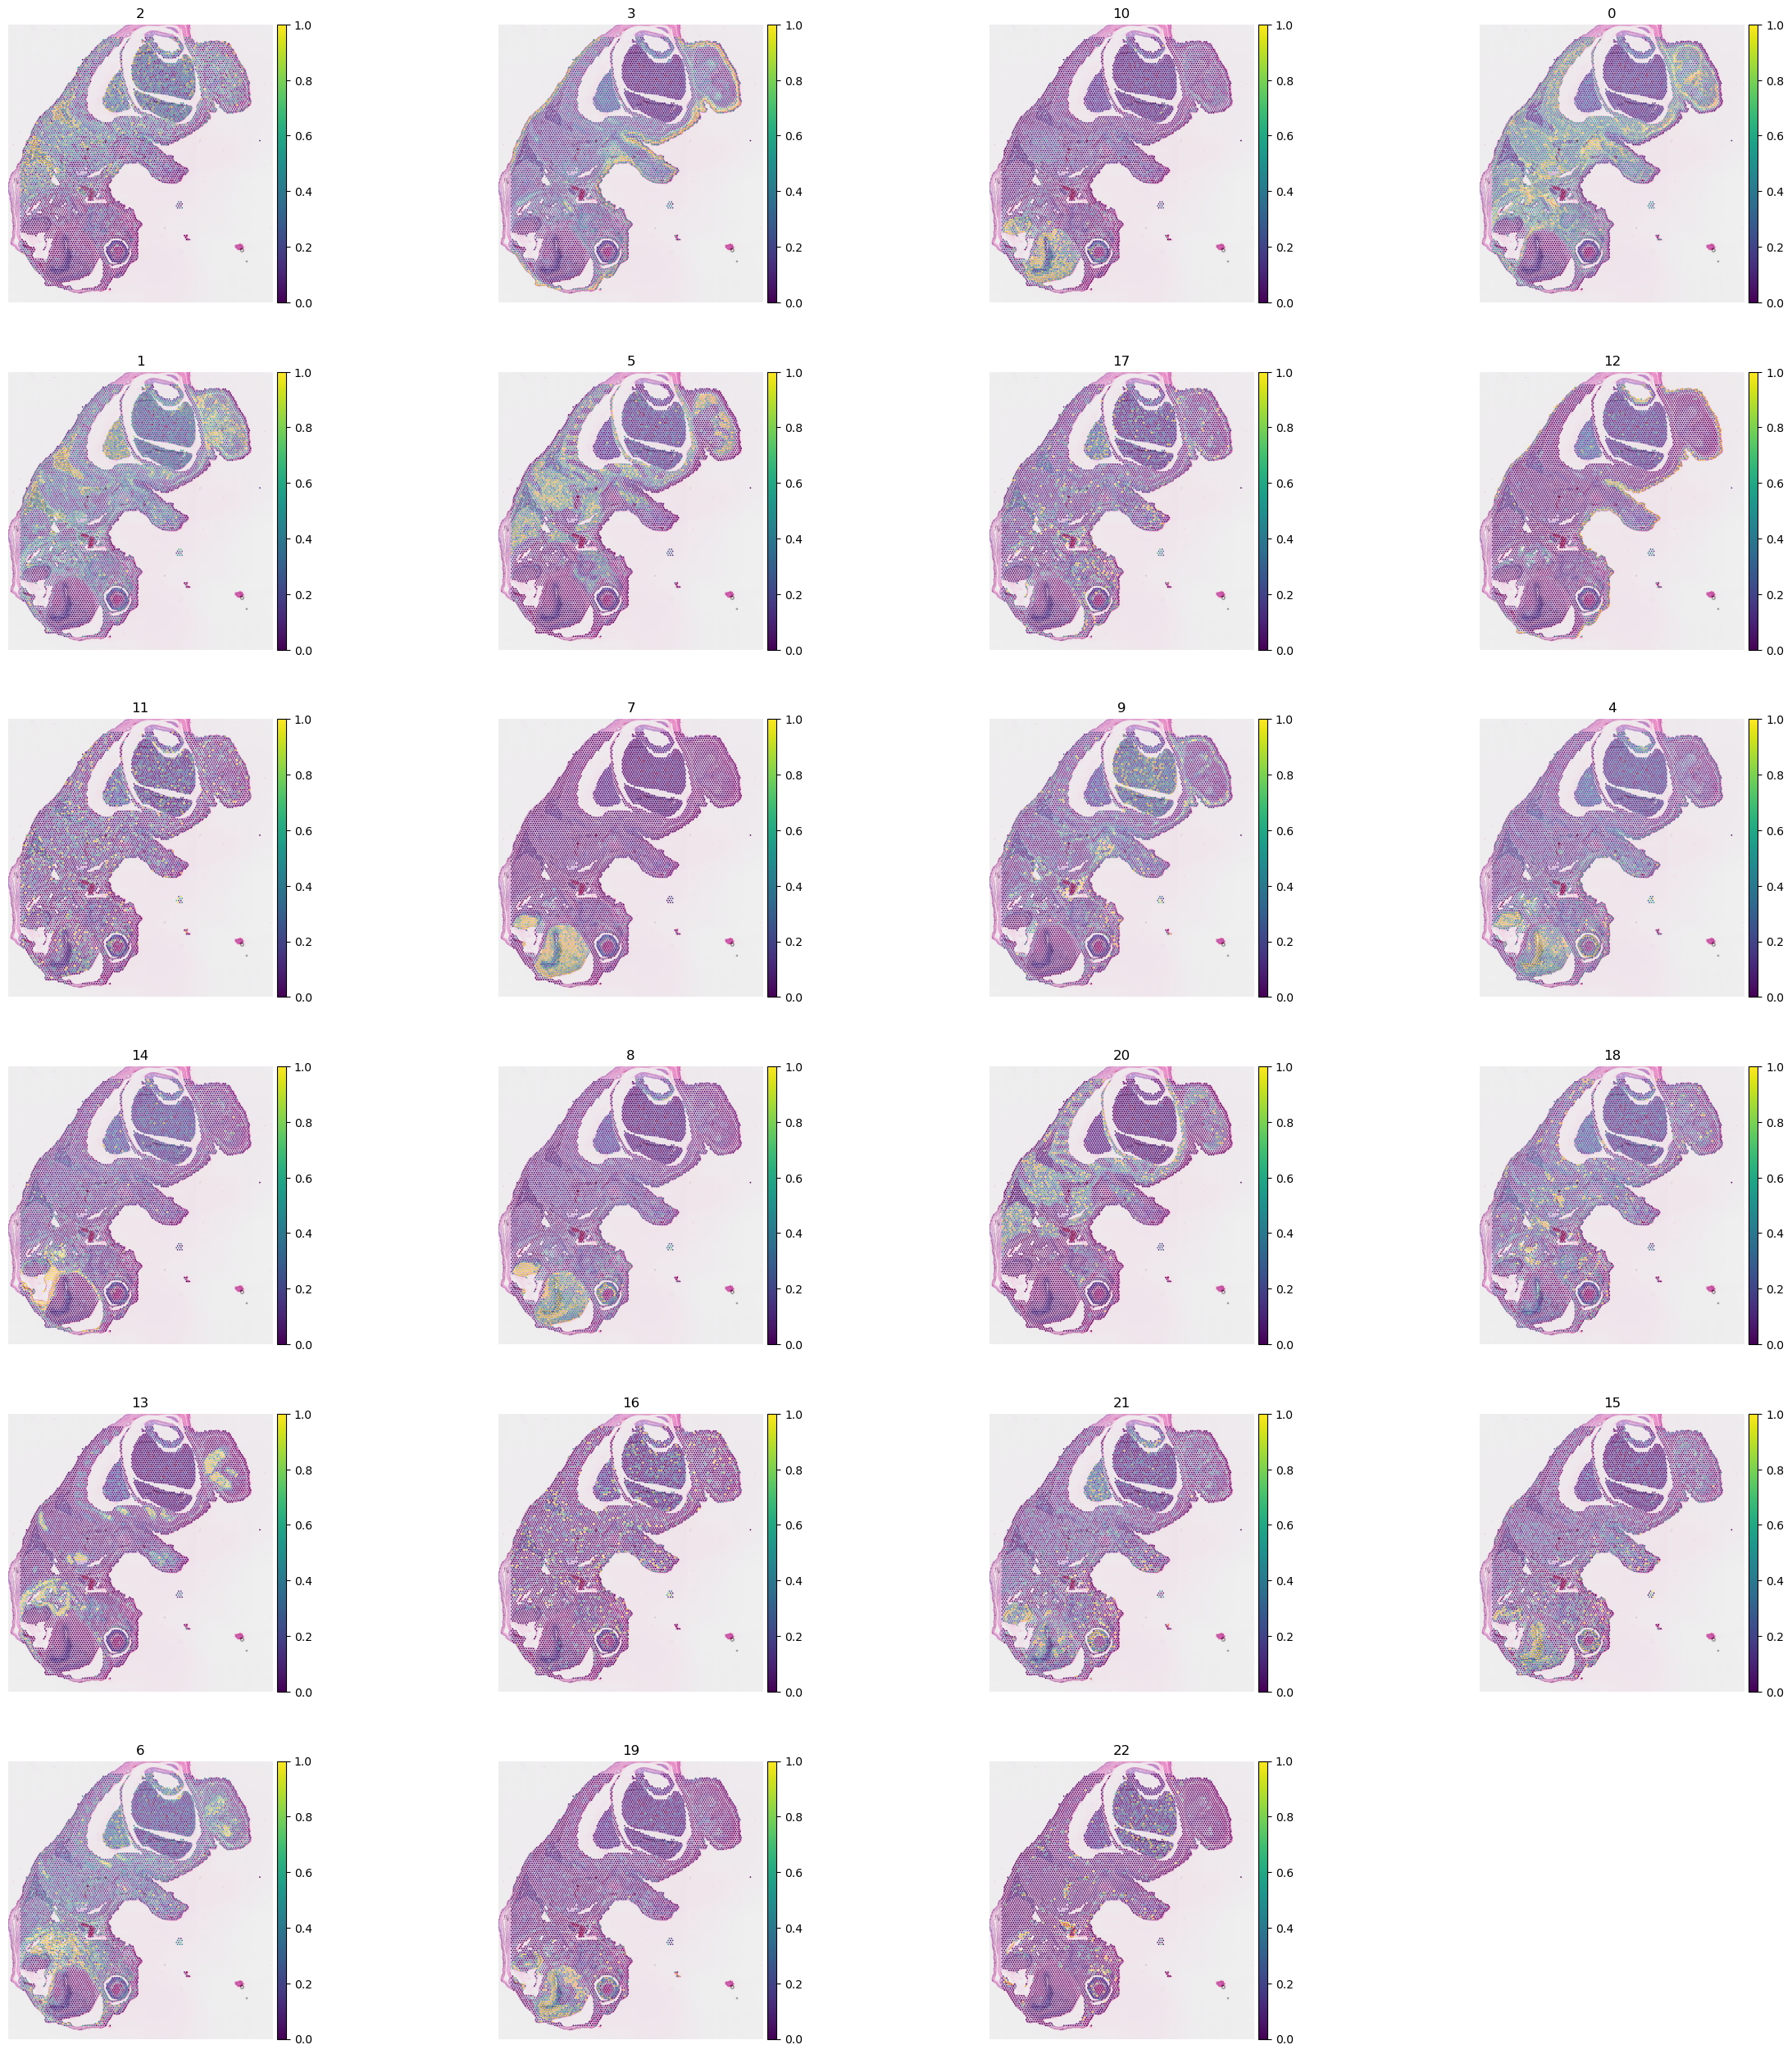

In [64]:
# cell type maps
tg.project_cell_annotations(ad_map, adata_st, annotation="leiden_0.4")
annotation_list = list(pd.unique(adata_sc.obs['leiden_0.4']))
tg.plot_cell_annotation_sc(adata_st, annotation_list,perc=0.02)

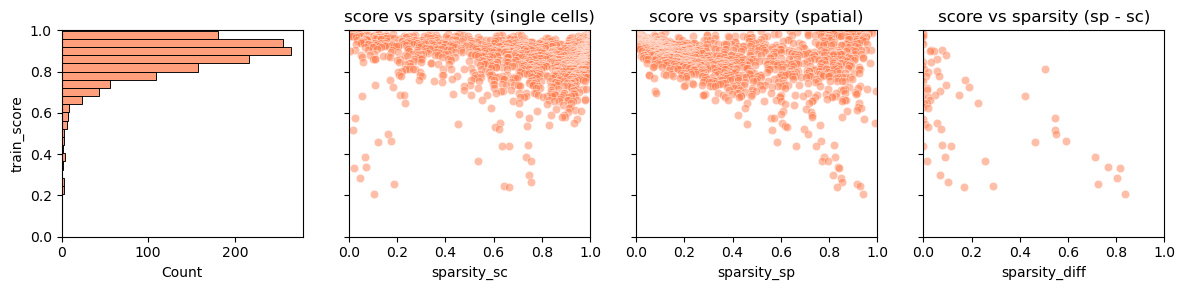

In [81]:
# metrics to see if the mapping is successful
tg.plot_training_scores(ad_map, bins=20, alpha=.5)

* The first panel is a histogram of the simlarity scores for each training gene.
* In the second panel, each dot is a training gene and we can observe the training score (y-axis) and the sparsity in the scRNA-seq data (x-axis) of each gene.
* The third panel is similar to the second one, but contains the gene sparsity of the spatial data. Spatial data are usually more sparse than single cell data, a discrepancy which is often responsible for low quality mapping.
* In the last panel, we show the training scores as a function of the difference in sparsity between the dataset. For genes with comparable sparsity, the mapped gene expression is very similar to that in the spatial data. However, if a gene is quite sparse in one dataset (typically, the spatial data) but not in other, the mapping score is lower. This occurs as Tangram cannot properly matched the gene pattern because of inconsistent amount of dropouts between the datasets.

In [82]:
# this contain gene expression data from the single cell (rather than visium) mapped onto the spatial data
ad_ge = tg.project_genes(adata_map=ad_map, adata_sc=adata_sc)
ad_ge

AnnData object with n_obs × n_vars = 6442 × 18973
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'summary_ch-0_mean', 'image_features_clusters', 'leiden_expr_spatial', 'leiden_expr_spatial_scaled', 'uniform_density', 'rna_count_based_density'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'sparsity', 'is_training'
    uns: 'DGEleiden0.01', 'DGEleiden0.025', 'DGEleiden0.05', 'DGEleiden0.1', 'DGEleiden0.15', 'DGEleiden0.2', 'DGEleiden0.4', 'ebf2+_sox9+_col2a1+_colors', 'ebf2+_sox9+_col2a1-_colors', 'hvg', 'leiden_0.01', 'leiden

In [92]:
ad_ge.write_h5ad('/Users/rikac/Documents/mansfield_lab/summer_25/ad_ge.h5ad')

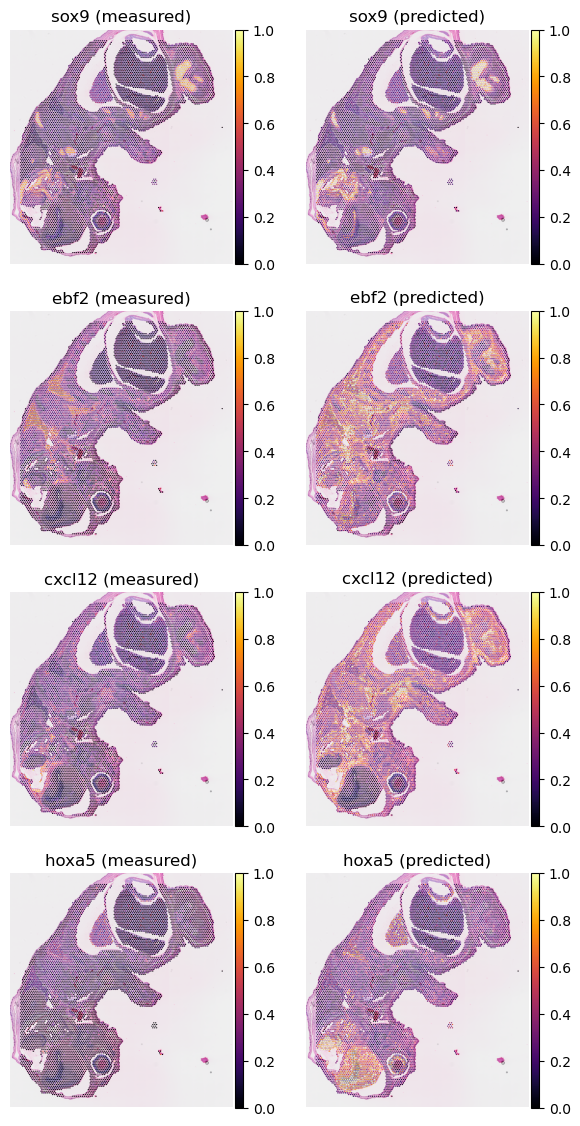

In [93]:
genes = ['sox9', 'ebf2', 'cxcl12', 'hoxa5']

# plot gene expression from the spatial data and tangram predicted mapping
tg.plot_genes_sc(genes, adata_measured=adata_st, adata_predicted=ad_ge, perc=0.02)

In [101]:
# auc curve
df_all_genes = tg.compare_spatial_geneexp(ad_ge, adata_st, adata_sc)
df_all_genes

,score,is_training,sparsity_sp,sparsity_sc,sparsity_diff
gltpd2,0.998107,True,0.842595,0.998970,-0.156374
ccn5,0.997419,True,0.918193,0.999099,-0.080906
agt,0.996808,True,0.516455,0.998884,-0.482430
tspo2,0.996705,True,0.638466,0.999142,-0.360675
gja6,0.996680,True,0.758150,0.998884,-0.240734
...,...,...,...,...,...
cxcl3,0.005428,False,0.998913,0.997468,0.001446
pate1,0.004780,False,0.989910,0.999142,-0.009232
ptgdr,0.000494,False,0.999379,0.998927,0.000452
slc24a1,0.000397,False,0.999534,0.998841,0.000693


<Figure size 640x480 with 0 Axes>

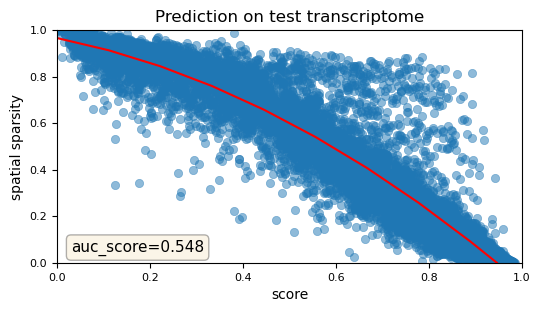

In [103]:
tg.plot_auc(df_all_genes)

# deconvolution

In [52]:
adata_st.uns['spatial']['CytAssist_11mm_FFPE_Mouse_Embryo']['scalefactors'].keys()

dict_keys(['fiducial_diameter_fullres', 'regist_target_img_scalef', 'spot_diameter_fullres', 'tissue_hires_scalef', 'tissue_lowres_scalef'])

In [47]:
# deconvolution
img_path = adata_st.uns['spatial']['CytAssist_11mm_FFPE_Mouse_Embryo']['images']['hires']
img = ImageContainer(img_path)

sq.im.process(img=img, layer="image", method="smooth")
sq.im.segment(
    img=img,
    layer="image_smooth",
    method="watershed",
    channel=0,
)

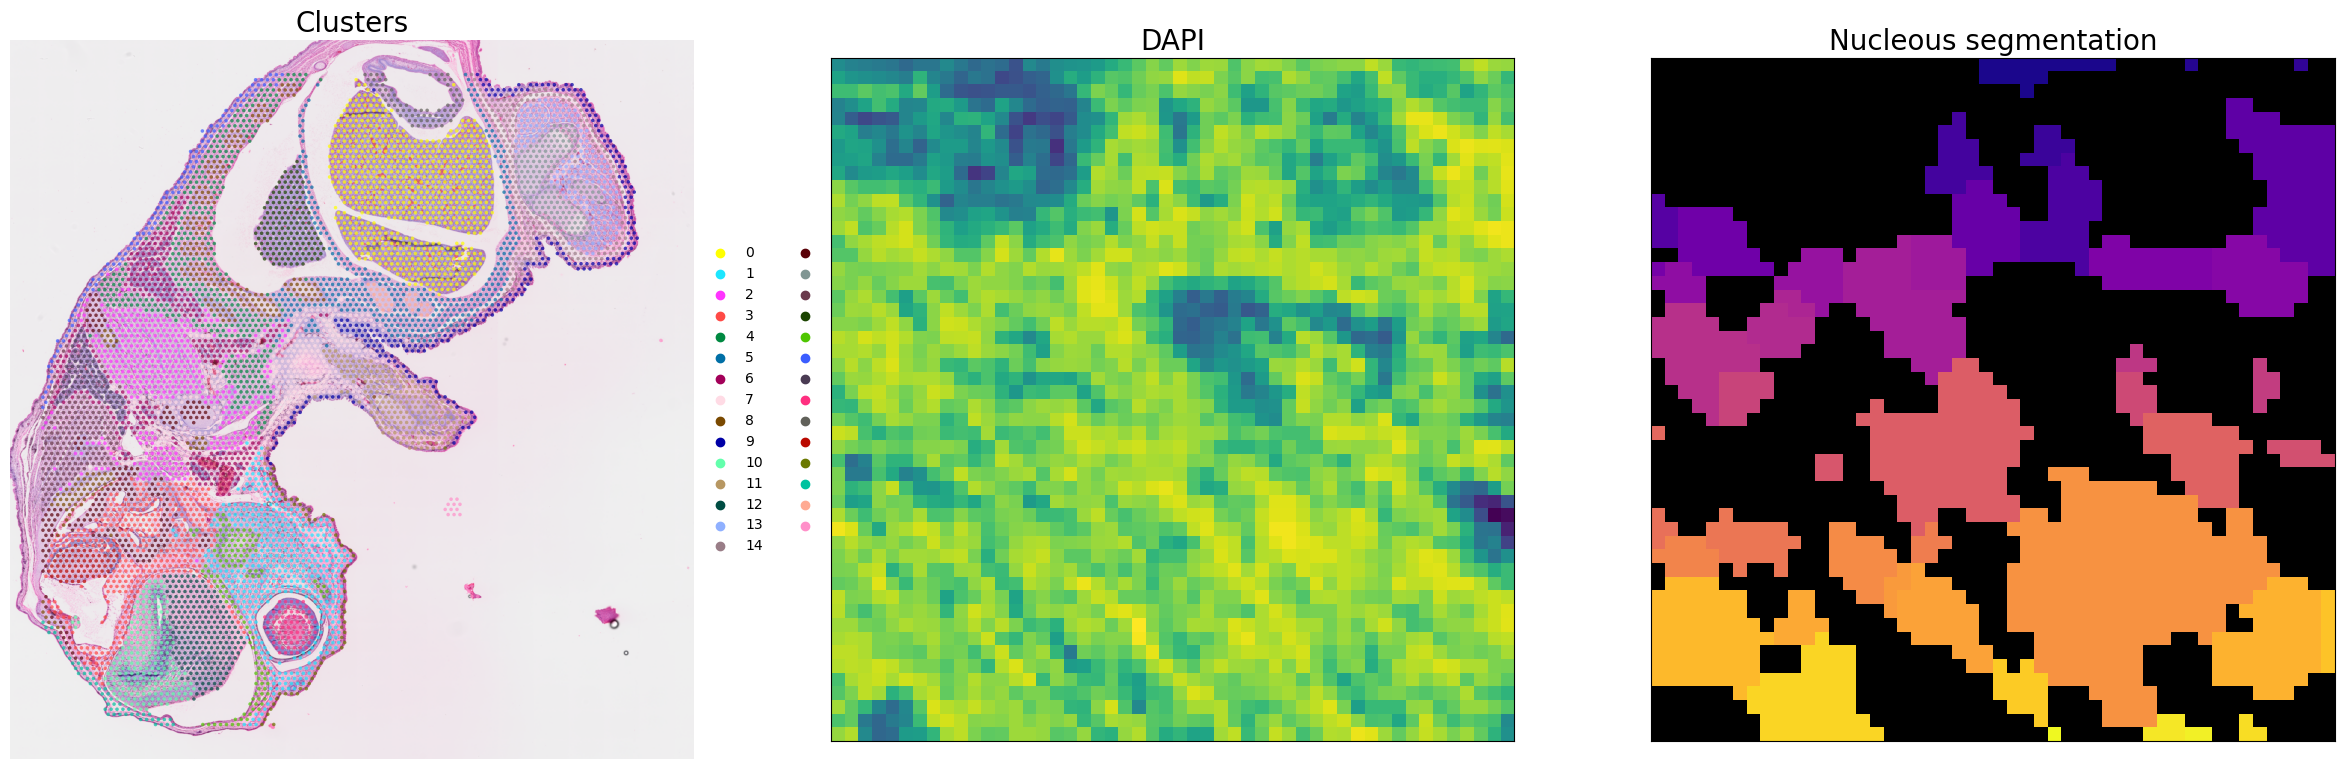

In [59]:
inset_y = 800
inset_x = 600
inset_sy = 50
inset_sx = 50

fig, axs = plt.subplots(1, 3, figsize=(30, 10))
sc.pl.spatial(
    adata_st, color="leiden_expr_spatial_scaled", alpha=0.7, frameon=False, show=False, ax=axs[0], title=""
)
axs[0].set_title("Clusters", fontdict={"fontsize": 20})
sf = adata_st.uns["spatial"]["CytAssist_11mm_FFPE_Mouse_Embryo"]["scalefactors"][
    "tissue_hires_scalef"
]
rect = mpl.patches.Rectangle(
    (inset_x * sf, inset_y * sf),
    width=inset_sx * sf,
    height=inset_sy * sf,
    ec="yellow",
    lw=4,
    fill=False,
)
axs[0].add_patch(rect)

axs[0].axes.xaxis.label.set_visible(False)
axs[0].axes.yaxis.label.set_visible(False)

axs[1].imshow(
    img["image"][inset_y : inset_y + inset_sy, inset_x : inset_x + inset_sx, 0, 0]
    / 65536,
    interpolation="none",
)
axs[1].grid(False)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title("DAPI", fontdict={"fontsize": 20})

crop = img["segmented_watershed"][
    inset_y : inset_y + inset_sy, inset_x : inset_x + inset_sx
].values.squeeze(-1)
crop = skimage.segmentation.relabel_sequential(crop)[0]
cmap = plt.cm.plasma
cmap.set_under(color="black")
axs[2].imshow(crop, interpolation="none", cmap=cmap, vmin=0.001)
axs[2].grid(False)
axs[2].set_xticks([])
axs[2].set_yticks([])
axs[2].set_title("Nucleous segmentation", fontdict={"fontsize": 20});